In [ ]:
# !pip install torchinfo -q

In [6]:
import os
import json
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torchinfo import summary


from sklearn.model_selection import train_test_split

# Config

In [7]:

path = '../data/ICPR 2026'
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Dataset config
vocab = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
num_classes = len(vocab)   # 36
label_len = 7
img_H, img_W = 32, 128

# Model config
embed_dim = 512
ff_dim = 512 * 4
num_layers = 3
num_heads = 8
drop_out = 0.1

# Training config
lr = 5e-4
batch_size = 64
epochs = 50
log_interval = 1
early_stop_count = 10
warmup_epochs = 3
train_loss = []
val_loss = []
train_acc = []
val_acc = []
best_model_path = '../weights/ConvNeXtTiny_BiLSTM_OCR.pth'

# Set Seed

In [8]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

In [9]:
print(len(os.listdir(os.path.join(path, 'train', 'Scenario-A', 'Brazilian'))) * 10)
print(len(os.listdir(os.path.join(path, 'train', 'Scenario-A', 'Mercosur'))) * 10)
print(len(os.listdir(os.path.join(path, 'train', 'Scenario-B', 'Brazilian'))) * 10)
print(len(os.listdir(os.path.join(path, 'train', 'Scenario-B', 'Mercosur'))) * 10)

49770
49600
19590
79520


# Dataset

In [15]:
class ICPRDataSet(Dataset):
    def __init__(self, path, split='train', val_size=0.2, random_state=42, transform=None):
        self.transform = transform
        self.split = split
        self.degradation = self.get_degradation_transforms()

        if split in ['train', 'val', 'test']:
            data_path = os.path.join(path, 'train')
            all_tracks = self.get_path(data_path, split='train')
            train_tracks, val_tracks = self.split_tracks(
                all_tracks, test_size=val_size, random_state=random_state
            )
            if split == 'train':
                self.tracks = train_tracks
            elif split == 'val':
                self.tracks = val_tracks
        elif split == 'test_label':
            data_path = os.path.join(path, 'test_label')
            self.tracks = self.get_path(data_path, split='test_label')
        elif split == 'blind_test':
            data_path = os.path.join(path, 'test')
            self.tracks = self.get_path(data_path, split='test')

        # Flatten thành list các entry, mỗi track tạo 2 entry khi train
        self.entries = self.build_entries(self.tracks)

        print(f'Split: {split}')
        print(f'Number of tracks: {len(self.tracks)}')
        print(f'Number of samples (entries): {len(self.entries)}')

    def get_path(self, path, split):
        tracks = {}
        track_paths = []

        if split == 'test' or split == 'test_label':
            track_names = os.listdir(path)
            for track_name in track_names:
                track_paths.append(os.path.join(path, track_name))
        else:
            scennarios = ['Scenario-A', 'Scenario-B']
            countries = ['Brazilian', 'Mercosur']
            for scennario in scennarios:
                for countrie in countries:
                    data_path = os.path.join(path, scennario, countrie)
                    if not os.path.isdir(data_path):
                        continue
                    for track_name in os.listdir(data_path):
                        track_paths.append(os.path.join(data_path, track_name))

        for track_path in track_paths:
            track_id = os.path.basename(track_path)
            track_lr = []
            track_hr = []
            track_label = None

            for item in os.listdir(track_path):
                item_path = os.path.join(track_path, item)
                if item.lower().startswith('lr'):
                    track_lr.append(item_path)
                elif item.lower().startswith('hr'):
                    track_hr.append(item_path)
                elif item.lower().endswith('.json') and split != 'test':
                    with open(item_path, 'r', encoding='utf-8') as f:
                        annotations = json.load(f)
                    track_label = annotations.get('plate_text').strip()

            tracks[track_id] = {
                'track_path': track_path,
                'lr_paths': sorted(track_lr),
                'hr_paths': sorted(track_hr),
                'label': track_label
            }

        return tracks

    def split_tracks(self, tracks, test_size=0.1, random_state=42):
        track_ids = sorted(tracks.keys())
        train_ids, val_ids = train_test_split(
            track_ids,
            test_size=test_size,
            random_state=random_state,
            shuffle=True
        )
        train_tracks = {tid: tracks[tid] for tid in train_ids}
        val_tracks = {tid: tracks[tid] for tid in val_ids}
        return train_tracks, val_tracks

    def build_entries(self, tracks):
        entries = []
        for track_id, track in tracks.items():
            # Entry 1: LR gốc
            entries.append({
                'entry_id': track_id + '_lr',
                'paths': track['lr_paths'],
                'use_hr': False,
                'label': track['label']
            })
            # Entry 2: HR-degrade (chỉ train)
            if self.split == 'train' and len(track['hr_paths']) > 0:
                entries.append({
                    'entry_id': track_id + '_hr',
                    'paths': track['hr_paths'],
                    'use_hr': True,
                    'label': track['label']
                })
        return entries

    def get_degradation_transforms(self):
        return A.Compose([
            A.OneOf([
                A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                A.MotionBlur(blur_limit=(3, 5), p=1.0)
            ], p=0.7),
            A.OneOf([
                A.GaussNoise(noise_scale_factor=0.1, p=1.0),
                A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0)
            ], p=0.7),
            A.ImageCompression(quality_range=(20, 50), p=0.5),
            A.Downscale(scale_range=(0.3, 0.5), p=0.5) 
        ])

    
    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        entry = self.entries[idx]

        images = []
        for img_path in entry['paths']:          # luôn đúng 5 frames
            img = np.array(Image.open(img_path).convert('RGB'))

            if entry['use_hr']:
                img = self.degradation(image=img)['image']  # HR → pseudo-LR

            if self.transform is not None:
                img = self.transform(image=img)['image']

            images.append(img)

        return {
            'track_id': entry['entry_id'],
            'images': images,                    # luôn 5 phần tử
            'label': entry['label']
        }

In [11]:
train_transforms = A.Compose([
    A.Resize(height=img_H, width=img_W),
    A.Affine(
        scale=(0.95, 1.05),
        translate_percent=(0.05, 0.05),
        rotate=(-5, 5),
        fill=128,
        p=0.5
    ),
    A.Perspective(scale=(0.02, 0.05), p=0.3),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),
    A.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=20,
            p=0.3
    ),
    A.ChannelShuffle(p=0.3),
    A.CoarseDropout(
            num_holes_range=(2, 5),
            hole_height_range=(4, 8),
            hole_width_range=(4, 8),
            p=0.3
    ),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

val_test_transforms = A.Compose([
    A.Resize(height=img_H, width=img_W),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

In [12]:
def encode_label(label: str) -> torch.Tensor:
    return torch.tensor(
        [vocab.index(c) for c in label.upper()],
        dtype=torch.long
    )  # shape (7,)

In [13]:
def collate_fn_train(batch):
    images = torch.stack([torch.stack(item['images']) for item in batch])
    # (B, F, C, H, W)
    targets = torch.stack([encode_label(item['label']) for item in batch])
    # (B, 7)
    return images, targets

def collate_fn_test(batch):
    images   = torch.stack([torch.stack(item['images']) for item in batch])
    targets  = torch.stack([encode_label(item['label']) for item in batch])
    track_ids = [item['track_id'] for item in batch]
    return images, targets, track_ids  

def collate_fn_blind_test(batch):
    images = torch.stack([torch.stack(item['images']) for item in batch])
    # (B, F, C, H, W)
    track_ids = [item['track_id'] for item in batch]
    return images, track_ids

In [16]:
train_dataset = ICPRDataSet(path, split='train', transform=train_transforms)
val_dataset = ICPRDataSet(path, split='val', transform=val_test_transforms)
test_dataset = ICPRDataSet(path, split='test_label', transform=val_test_transforms)
blind_test_dataset = ICPRDataSet(path, split='blind_test', transform=val_test_transforms)

Split: train
Number of tracks: 15878
Number of samples (entries): 31756
Split: val
Number of tracks: 3970
Number of samples (entries): 3970
Split: test_label
Number of tracks: 152
Number of samples (entries): 152
Split: blind_test
Number of tracks: 1000
Number of samples (entries): 1000


In [17]:
# num_workers=4,       
# pin_memory=True 


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn_train,     
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn_train,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn_test,
)

blind_test_loader = DataLoader(
    blind_test_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=collate_fn_blind_test
)

In [18]:
def unnormalize(tensor):
    """tensor: (C, H, W)"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


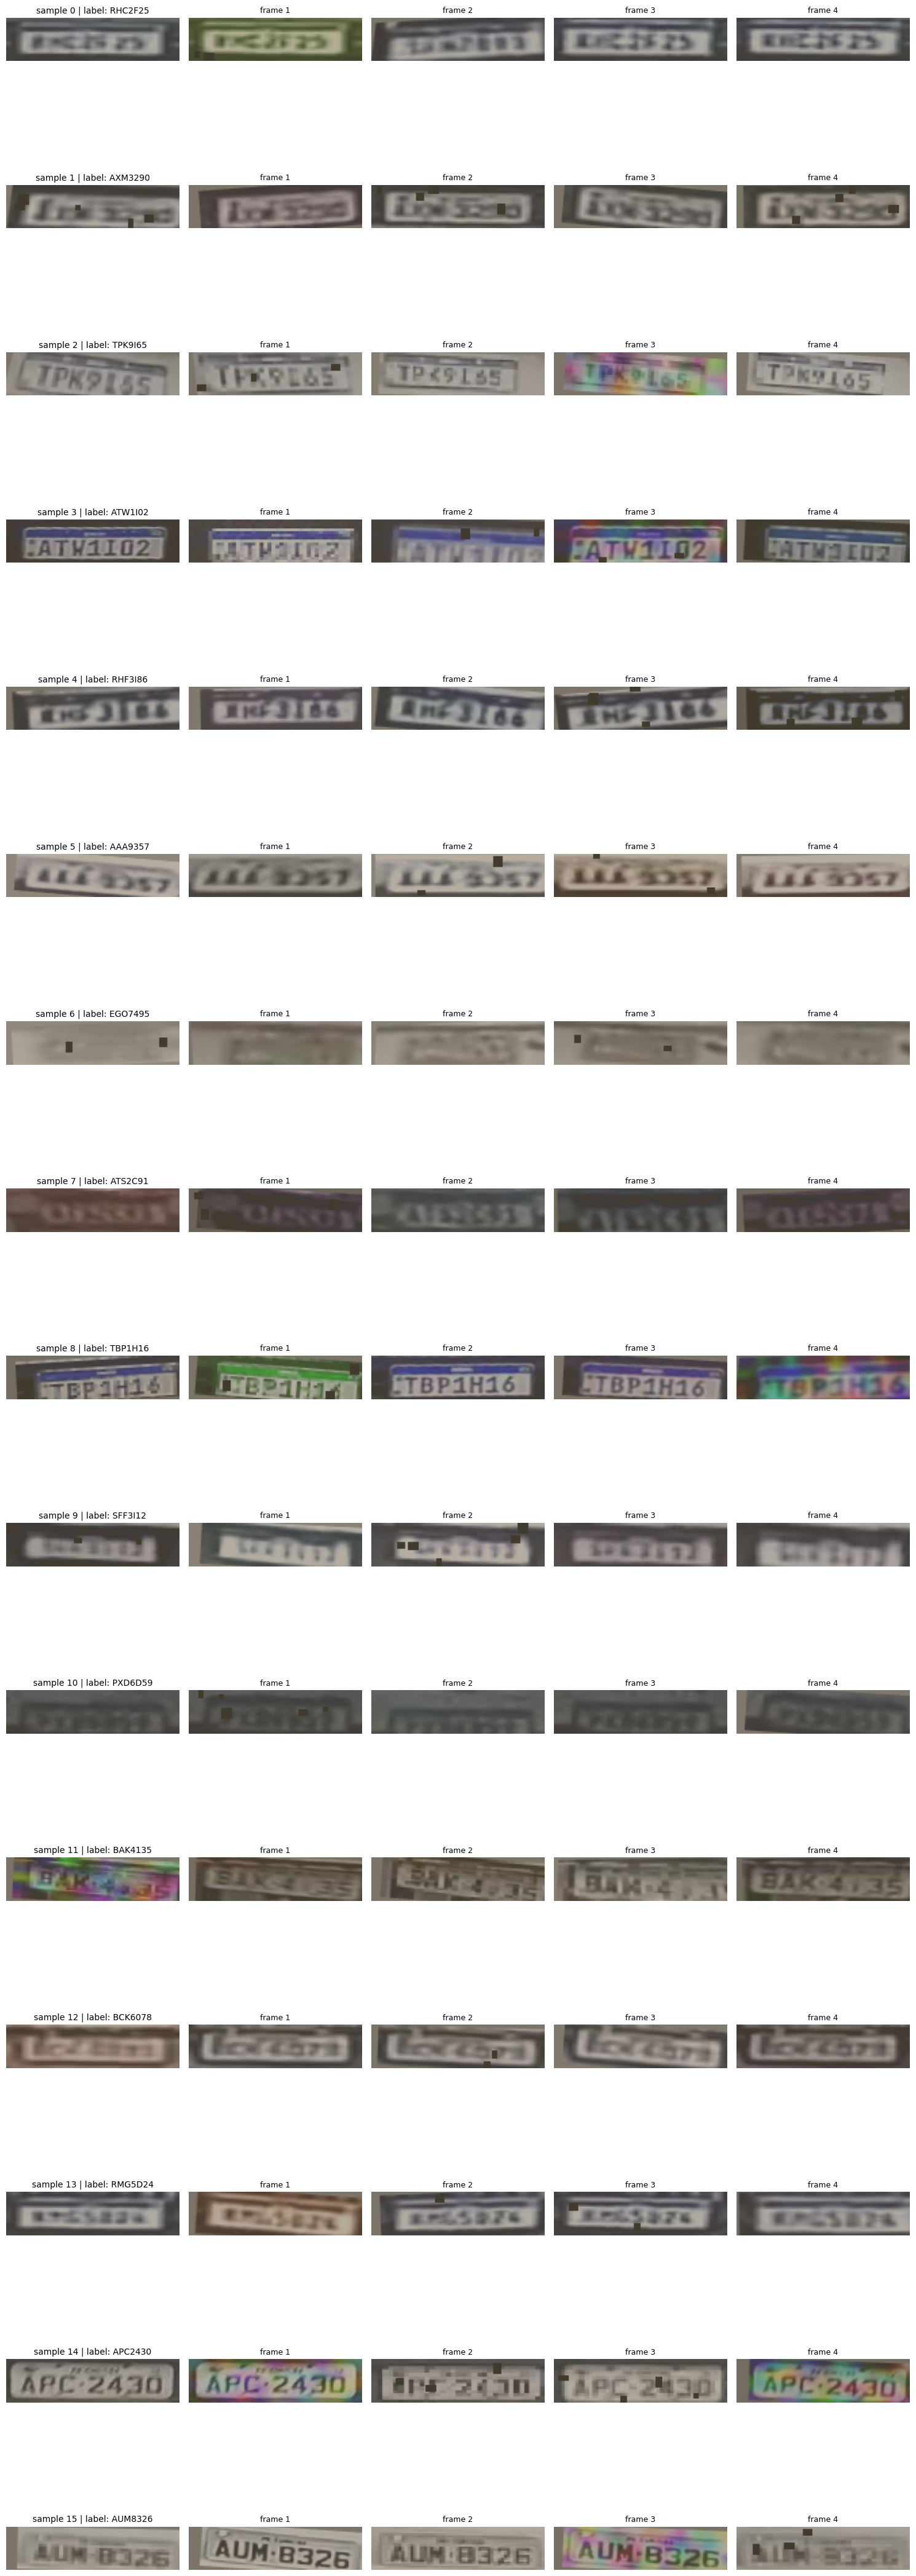

Batch shape: torch.Size([64, 5, 3, 32, 128]), Targets shape: torch.Size([64, 7])


In [19]:
# Visualize one batch from train_loader
images, targets = next(iter(train_loader))  # images: (B, F, C, H, W), targets: (B, 7)

B, Fm, C, H, W = images.shape
show_samples = min(16, B)
show_frames = min(5, Fm)

fig, axes = plt.subplots(show_samples, show_frames, figsize=(3 * show_frames, 2.8 * show_samples))

# Normalize axes shape for cases when rows/cols == 1
if show_samples == 1 and show_frames == 1:
    axes = np.array([[axes]])
elif show_samples == 1:
    axes = axes[np.newaxis, :]
elif show_frames == 1:
    axes = axes[:, np.newaxis]

for i in range(show_samples):
    label_str = ''.join(vocab[idx] for idx in targets[i].tolist())
    for j in range(show_frames):
        img = unnormalize(images[i, j].cpu())

        ax = axes[i, j]
        ax.imshow(img)
        ax.axis('off')
        if j == 0:
            ax.set_title(f'sample {i} | label: {label_str}', fontsize=10)
        else:
            ax.set_title(f'frame {j}', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Batch shape: {images.shape}, Targets shape: {targets.shape}')

# Baseline 1: Multi Frame ORC - ResNet50 + Transformer

In [20]:
class STNBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.localization = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=5, stride=2, padding=2),
            nn.MaxPool2d(2, 2),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(True),
            nn.AdaptiveAvgPool2d((4, 8))
        )
        self.fc_loc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 8, 128),
            nn.ReLU(True),
            nn.Linear(128, 6)
        )
        with torch.no_grad():
            self.fc_loc[-1].weight.zero_()
            self.fc_loc[-1].bias.copy_(
                torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float)
            )
    
    def forward(self, x):
        x = self.localization(x)
        x = self.fc_loc(x)
        x = x.view(-1, 2, 3)
        return x

In [21]:
class FeatureExtractor(nn.Module):
    def __init__(self, pretrained=True, out_dim=512, freeze_backbone=False):
        super().__init__()
        weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = convnext_tiny(weights=weights)

        self.features = backbone.features

        # ConvNeXt-Tiny feature map sizes for input (32, 128):
        #   After stem  (features[0]): (8, 32),  96ch
        #   After ds     features[2]:  (4, 16), 192ch
        #   After ds     features[4]:  (2, 16), 384ch  <- modify here
        #   After ds     features[6]:  (1, 16), 768ch  <- modify here
        #
        # Downsampling conv: kernel_size=2, stride=2.
        # Modify stride (2,2) -> (2,1) AND kernel_size (2,2) -> (2,1)
        # so that height halves but width is fully preserved:
        #   H_out = (H - 2) / 2 + 1 = H // 2
        #   W_out = (W - 1) / 1 + 1 = W  (unchanged)
        for ds_idx in [4, 6]:
            conv = self.features[ds_idx][1]   # Conv2d inside Sequential
            conv.stride      = (2, 1)
            conv.kernel_size = (2, 1)
            # Slice pretrained weight: keep first 1 column (height-kernel stays 2, width-kernel becomes 1)
            # weight shape: (out_ch, in_ch, kH, kW) = (..., 2, 2) -> (..., 2, 1)
            import torch
            with torch.no_grad():
                conv.weight = nn.Parameter(conv.weight[:, :, :, :1].contiguous())

        # ConvNeXt-Tiny final output = 768 channels
        self.proj = nn.Conv2d(768, out_dim, kernel_size=1)

        if freeze_backbone:
            for name, p in self.named_parameters():
                if 'proj' not in name:
                    p.requires_grad = False

    def forward(self, x):
        x = self.features(x)
        x = self.proj(x)                              # (B, out_dim, H', W')
        # Collapse height -> 1, keep width as sequence (same as baseline)
        x = F.adaptive_avg_pool2d(x, (1, None))       # (B, out_dim, 1, W')
        return x

In [22]:
class AttentionFusion(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.score_net = nn.Sequential(
            nn.Conv2d(channels, channels // 8, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // 8, 1, kernel_size=1)
        )

    def forward(self, x):
        total_frames, C, H, W = x.size()
        num_frames = 5
        batch_size = total_frames // num_frames

        # Reshape to [Batch_size, Frames, C, H, W]
        x_view = x.view(batch_size, num_frames, C, H, W)

        # Calculate attention scores [Batch_size, Frames, 1, H, W]
        scores = self.score_net(x).view(batch_size, num_frames, 1, H, W)
        weights = F.softmax(scores, dim=1)

        # Weight sim fusion
        fused_features = torch.sum(x_view * weights, dim=1)
        return fused_features

In [25]:
class BiLSTMEncoder(nn.Module):
    """
    3-layer Bidirectional LSTM encoder.
    hidden_size = embed_dim // 2  so that concat of both directions = embed_dim.
    Residual projection keeps dimension consistent across layers.
    """
    def __init__(self, embed_dim, num_layers=3, drop_out=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=embed_dim // 2,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=drop_out if num_layers > 1 else 0.0
        )
        self.norm    = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(drop_out)

    def forward(self, x):
        # x: (B, T, embed_dim)
        out, _ = self.lstm(x)          # (B, T, embed_dim)
        out = self.dropout(out)
        out = self.norm(out)
        return out                     # (B, T, embed_dim)

In [26]:
class ResTranOCR(nn.Module):
    def __init__(self, label_len, num_classes, embed_dim, ff_dim, num_layers, num_heads,
                 extractor_pretrained=True, freeze_extractor=True, drop_out=0.1):
        super().__init__()
        self.label_len     = label_len
        self.stn           = STNBlock(3)
        self.extractor     = FeatureExtractor(pretrained=extractor_pretrained,
                                      out_dim=embed_dim,
                                      freeze_backbone=freeze_extractor)
        self.attn_fusion   = AttentionFusion(embed_dim)
        # BiLSTM encoder: num_layers deep, embed_dim in/out
        self.sequence_model = BiLSTMEncoder(
            embed_dim=embed_dim,
            num_layers=num_layers,
            drop_out=drop_out
        )
        self.head = nn.Linear(embed_dim, num_classes)  # 36

    def forward(self, x):
        B, Frames, C, H, W = x.size()

        x_flat    = x.view(B * Frames, C, H, W)
        theta     = self.stn(x_flat)
        grid      = F.affine_grid(theta, x_flat.size(), align_corners=False)
        x_aligned = F.grid_sample(x_flat, grid, align_corners=False)

        features  = self.extractor(x_aligned)       # (B*F, embed_dim, H', W')
        fused     = self.attn_fusion(features)       # (B, embed_dim, H', W')

        # (B, W', embed_dim) — no positional encoding needed for LSTM
        seq_input = fused.squeeze(2).permute(0, 2, 1)
        seq_out   = self.sequence_model(seq_input)   # (B, T, embed_dim)

        seq_out = seq_out.permute(0, 2, 1)           # (B, embed_dim, T)
        seq_out = F.adaptive_avg_pool1d(seq_out, self.label_len)  # (B, embed_dim, 7)
        seq_out = seq_out.permute(0, 2, 1)           # (B, 7, embed_dim)

        out = self.head(seq_out)                     # (B, 7, 36)
        return out

In [27]:
model = ResTranOCR(
    label_len=label_len,
    num_classes=num_classes,
    embed_dim=embed_dim,
    ff_dim=ff_dim,
    num_layers=num_layers,
    num_heads=num_heads,
    extractor_pretrained=True,
    freeze_extractor=True,
    drop_out=drop_out
    ).to(device)

In [28]:
summary(model, input_size=(1, 5, 3, img_H, img_W), device=device)

Layer (type:depth-idx)                             Output Shape              Param #
ResTranOCR                                         [1, 7, 36]                --
├─STNBlock: 1-1                                    [5, 2, 3]                 --
│    └─Sequential: 2-1                             [5, 64, 4, 8]             --
│    │    └─Conv2d: 3-1                            [5, 32, 16, 64]           2,432
│    │    └─MaxPool2d: 3-2                         [5, 32, 8, 32]            --
│    │    └─ReLU: 3-3                              [5, 32, 8, 32]            --
│    │    └─Conv2d: 3-4                            [5, 64, 8, 32]            18,496
│    │    └─ReLU: 3-5                              [5, 64, 8, 32]            --
│    │    └─AdaptiveAvgPool2d: 3-6                 [5, 64, 4, 8]             --
│    └─Sequential: 2-2                             [5, 6]                    --
│    │    └─Flatten: 3-7                           [5, 2048]                 --
│    │    └─Linear: 3-8     

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs, eta_min=1e-6
)

In [29]:
def decode_pred(logits):
    """logits: (B, 7, 36) → list of str"""
    indices = logits.argmax(dim=2)  # (B, 7)
    return ["".join(vocab[i] for i in seq.tolist()) for seq in indices]

In [30]:
def compute_accuracy(logits, targets):
    """Sequence accuracy — đúng cả 7 ký tự mới tính đúng"""
    preds = logits.argmax(dim=2)    # (B, 7)
    correct = (preds == targets).all(dim=1).sum().item()
    return correct / targets.size(0)

In [31]:
def postprocess_rule_base(pred: str) -> str:
    D2C = {'0':'O','1':'I','2':'Z','5':'S','6':'G','8':'B','4':'A'}
    C2D = {v: k for k, v in D2C.items()}

    chars = list(pred.upper())

    for i in [0, 1, 2]:         
        if chars[i] in D2C:
            chars[i] = D2C[chars[i]]

    if chars[3] in C2D:        
        chars[3] = C2D[chars[3]]

    if chars[4] == 'O':          
        chars[4] = '0'

    for i in [5, 6]:             
        if chars[i] in C2D:
            chars[i] = C2D[chars[i]]

    return ''.join(chars)

In [32]:
def compute_accuracy_postprocess(logits, targets):
    preds = prediction_from_logits(logits)         
    gt    = [''.join(vocab[i] for i in t.tolist()) for t in targets]
    correct = sum(p == g for p, g in zip(preds, gt))
    return correct / len(gt)


def prediction_from_logits(logits):
    indices = logits.argmax(dim=2).cpu()
    preds = [''.join(vocab[i] for i in seq.tolist()) for seq in indices]
    return [postprocess_rule_base(p) for p in preds]


def prediction(model, images, device):
    model.eval()
    with torch.no_grad():
        logits = model(images.to(device))
    return prediction_from_logits(logits)

In [33]:
# For multi-gpu
if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

# Training

In [ ]:
def visualize_val_samples(model, val_loader, device, n_samples=2):
    """Lấy batch đầu val, show n_samples — mỗi sample 1 hàng gồm frame 0."""
    model.eval()
    images, targets = next(iter(val_loader))
    images_dev = images[:n_samples].to(device)

    with torch.no_grad():
        logits = model(images_dev)                     # (n, 7, 36)

    preds = decode_pred(logits.cpu())                  # list of str
    gts   = [''.join(vocab[i] for i in t.tolist())
              for t in targets[:n_samples]]            # list of str

    fig, axes = plt.subplots(
        n_samples, 1,
        figsize=(6, 2.5 * n_samples)
    )
    if n_samples == 1:
        axes = [axes]

    for i in range(n_samples):
        ax = axes[i]
        img = unnormalize(images[i, 0].cpu())          # frame 0, (H,W,C)
        ax.imshow(img)
        ax.axis('off')

        correct = preds[i] == gts[i]
        color   = 'green' if correct else 'red'
        ax.set_title(
            f'GT: {gts[i]}   |   Pred: {preds[i]}',
            fontsize=11, color=color, fontweight='bold'
        )

    plt.suptitle('Val sample preview', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
def train(model, optimizer, scheduler, criterion,
          train_loader, val_loader,
          epochs, early_stop_count, best_model_path,
          log_interval, warmup_epochs=0, device='cpu'):

    best_val_acc = 0.0
    break_count  = 0
    train_loss_hist, val_loss_hist = [], []
    train_acc_hist,  val_acc_hist  = [], []
    val_acc_post_hist = []                          # ✅ THÊM

    base_model = model.module if isinstance(model, nn.DataParallel) else model

    if warmup_epochs > 0:
        for p in base_model.extractor.parameters():
            p.requires_grad = False

    for epoch in tqdm(range(epochs), desc='Epoch', position=0):

        if warmup_epochs > 0 and epoch == warmup_epochs:
            for p in base_model.extractor.parameters():
                p.requires_grad = True

        # ── Train ──────────────────────────────────────────
        model.train()
        if warmup_epochs > 0 and epoch < warmup_epochs:
            base_model.extractor.eval()

        epoch_loss = epoch_acc = 0

        for images, targets in tqdm(train_loader, desc='Train', position=1, leave=False):
            images  = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss   = criterion(logits.permute(0, 2, 1), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            epoch_loss += loss.item()
            epoch_acc  += compute_accuracy(logits.detach().cpu(), targets.cpu())

        train_loss_hist.append(epoch_loss / len(train_loader))
        train_acc_hist.append(epoch_acc  / len(train_loader))

        # ── Validation ─────────────────────────────────────
        model.eval()
        epoch_loss = epoch_acc = epoch_acc_post = 0   # ✅ THÊM epoch_acc_post

        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc='Val', position=1, leave=False):
                images  = images.to(device)
                targets = targets.to(device)

                logits = model(images)
                loss   = criterion(logits.permute(0, 2, 1), targets)

                epoch_loss     += loss.item()
                epoch_acc      += compute_accuracy(logits.cpu(), targets.cpu())
                epoch_acc_post += compute_accuracy_postprocess(logits.cpu(), targets.cpu())  

        val_loss_hist.append(epoch_loss / len(val_loader))
        val_acc_hist.append(epoch_acc   / len(val_loader))
        val_acc_post_hist.append(epoch_acc_post / len(val_loader))                           

        scheduler.step()

        # ── Log ────────────────────────────────────────────
        if epoch % log_interval == 0:
            print(
                f'| Epoch {epoch:3d} '
                f'| Train Loss {train_loss_hist[-1]:.4f}  Acc {train_acc_hist[-1]:.4f} '
                f'| Val Loss {val_loss_hist[-1]:.4f}  Acc {val_acc_hist[-1]:.4f} '
                f'| Val Acc (post) {val_acc_post_hist[-1]:.4f} |'   
            )
            visualize_val_samples(model, val_loader, device, n_samples=2)

        # ── Checkpoint + Early stop (giữ nguyên theo raw acc) ──
        if val_acc_hist[-1] > best_val_acc:
            break_count  = 0
            best_val_acc = val_acc_hist[-1]
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     base_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_acc':         val_acc_hist[-1],
                'break_count':          break_count,
                'train_loss_hist':      train_loss_hist,
                'val_loss_hist':        val_loss_hist,
                'train_acc_hist':       train_acc_hist,
                'val_acc_hist':         val_acc_hist,
                'val_acc_post_hist':    val_acc_post_hist,   
            }, best_model_path)
        else:
            break_count += 1

        if break_count >= early_stop_count:
            print(f'Early stop tại epoch {epoch} | best val acc: {best_val_acc:.4f}')
            break

        train_loss.append(train_loss_hist[-1])
        val_loss.append(val_loss_hist[-1])
        train_acc.append(train_acc_hist[-1])
        val_acc.append(val_acc_hist[-1])

    checkpoint = torch.load(best_model_path, map_location=device)
    base_model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print('Training hoàn tất, đã load best model')

    return model, {
        'train_loss':      train_loss_hist,
        'val_loss':        val_loss_hist,
        'train_acc':       train_acc_hist,
        'val_acc':         val_acc_hist,
        'val_acc_post':    val_acc_post_hist,  
    }

In [ ]:
model, metrics = train(
    model, optimizer, scheduler, criterion, train_loader, val_loader, epochs, early_stop_count,
    best_model_path, log_interval, warmup_epochs, device
)



# Visual loss and acc

In [34]:
checkpoint = torch.load(best_model_path, map_location=device)
state_dict = checkpoint.get('model_state_dict', checkpoint)
train_loss_hint = checkpoint.get('train_loss_hist', checkpoint)
val_loss_hint = checkpoint.get('val_loss_hist', checkpoint)
train_acc_hint = checkpoint.get('train_acc_hist', checkpoint)
val_acc_hint = checkpoint.get('val_acc_hist', checkpoint)

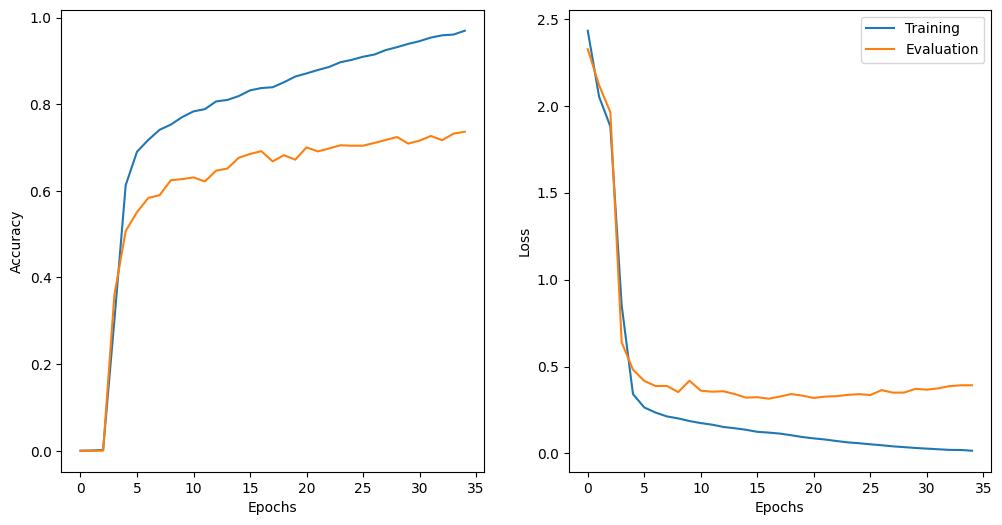

In [35]:
def plot_result(num_epochs, train_accs, eval_accs, train_losses, eval_losses):
    epochs = list(range(num_epochs))
    fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
    axs[0].plot(epochs, train_accs, label = "Training")
    axs[0].plot(epochs, eval_accs, label = "Evaluation")
    axs[1].plot(epochs, train_losses, label = "Training")
    axs[1].plot(epochs, eval_losses, label = "Evaluation")
    axs[0].set_xlabel("Epochs")
    axs[1].set_xlabel("Epochs")
    axs[0].set_ylabel("Accuracy")
    axs[1].set_ylabel("Loss")
    plt.legend()


plot_result(
    35,
    train_acc_hint,
    val_acc_hint,
    train_loss_hint,
    val_loss_hint
)

# Evalute


In [36]:
checkpoint = torch.load(best_model_path, map_location=device)
state_dict = checkpoint.get('model_state_dict', checkpoint)

try:
    model.load_state_dict(state_dict)
except RuntimeError:
    if any(k.startswith('module.') for k in state_dict.keys()):
        state_dict = {k.replace('module.', '', 1): v for k, v in state_dict.items()}
    else:
        state_dict = {f'module.{k}': v for k, v in state_dict.items()}
    model.load_state_dict(state_dict)

model.eval()

ResTranOCR(
  (stn): STNBlock(
    (localization): Sequential(
      (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
      (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
      (5): AdaptiveAvgPool2d(output_size=(4, 8))
    )
    (fc_loc): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=2048, out_features=128, bias=True)
      (2): ReLU(inplace=True)
      (3): Linear(in_features=128, out_features=6, bias=True)
    )
  )
  (extractor): FeatureExtractor(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1

In [37]:
def visualize_predictions(model, loader, device='cpu', n_samples=6, mode='test'):
    """
    mode='test'       : hiện track_id, GT label, prediction (màu xanh/đỏ)
    mode='blind_test' : hiện track_id, prediction only
    """
    model.eval()

    batch = next(iter(loader))
    if mode == 'test':
        images, targets, track_ids = batch   # collate_fn_test phải trả thêm targets
    else:
        images, track_ids = batch

    images = images.to(device)
    with torch.no_grad():
        logits = model(images)
        preds  = decode_pred(logits.cpu())

    images_cpu = images.detach().cpu()
    n_samples  = min(n_samples, images_cpu.size(0))
    n_frames   = images_cpu.size(1)

    fig, axes = plt.subplots(
        n_samples, n_frames,
        figsize=(n_frames * 3, n_samples * 2.5)
    )
    if n_samples == 1:
        axes = [axes]

    for row_idx in range(n_samples):
        pred_label = preds[row_idx]
        track_id   = track_ids[row_idx]

        if mode == 'test':
            gt = ''.join(vocab[i] for i in targets[row_idx].tolist())
            correct = pred_label == gt
            color   = '#4CAF50' if correct else '#F44336'  # xanh nếu đúng, đỏ nếu sai
            title   = f'{track_id}\nGT: {gt}  |  Pred: {pred_label}'
        else:
            color = '#2196F3'
            title = f'{track_id}\nPred: {pred_label}'

        for col_idx in range(n_frames):
            ax  = axes[row_idx][col_idx]
            img = unnormalize(images_cpu[row_idx, col_idx])
            ax.imshow(img)
            ax.axis('off')
            ax.set_xlabel(f'frame {col_idx + 1}', fontsize=7, labelpad=2)

            if col_idx == 0:
                ax.set_title(title, fontsize=9, fontweight='bold',
                             color=color, loc='left', pad=3)

    plt.suptitle(
        f'{"Test" if mode == "test" else "Blind Test"} — Inference Preview',
        fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(f'inference_preview_{mode}.png', dpi=120, bbox_inches='tight')
    plt.show()

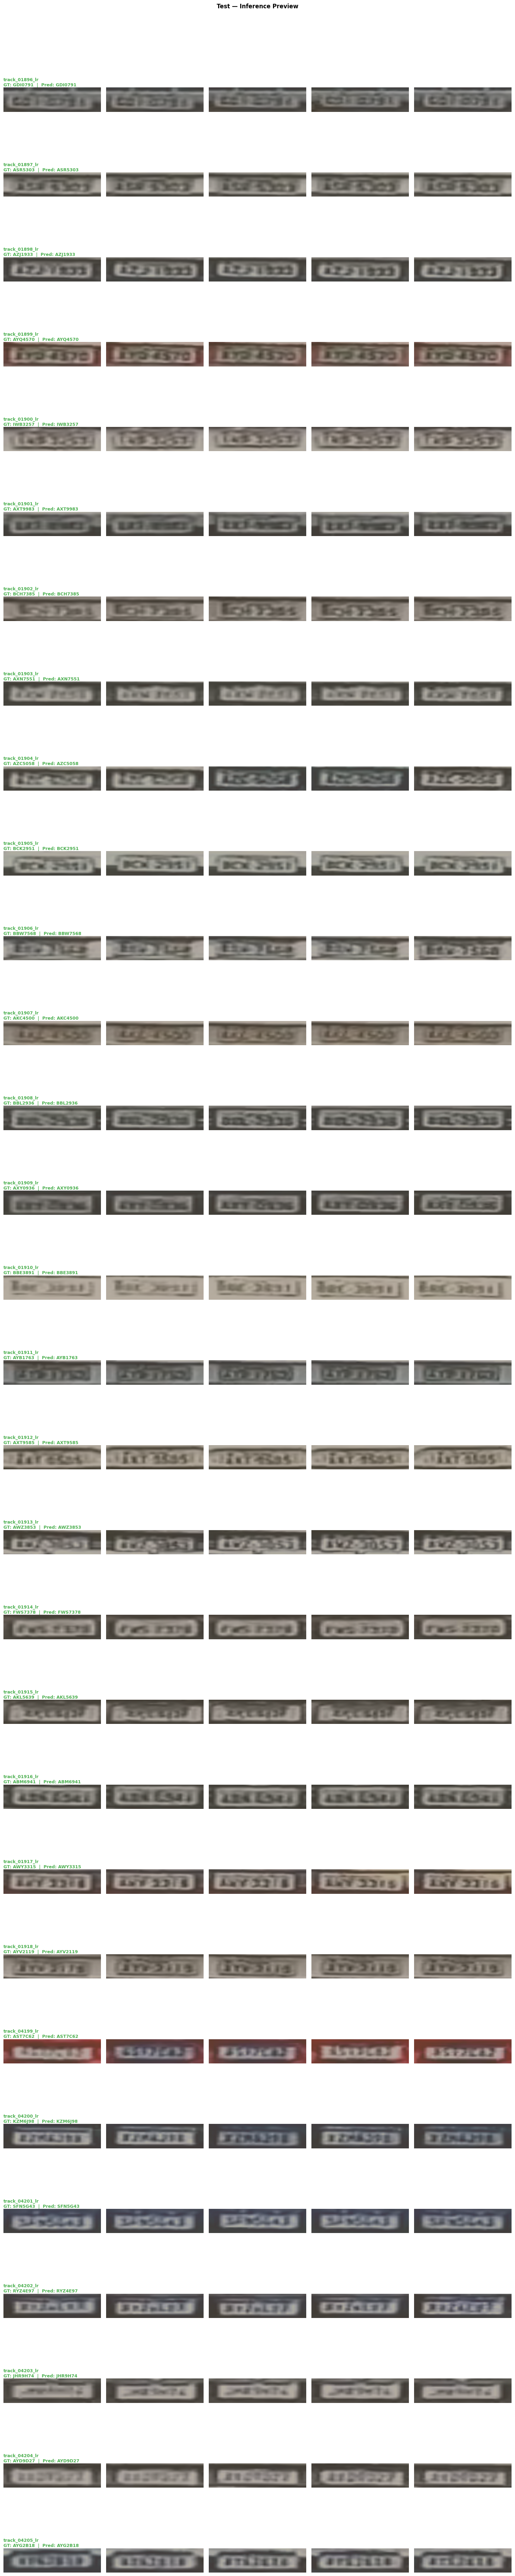

In [40]:
visualize_predictions(model, test_loader, device=device, n_samples=30, mode='test')

In [ ]:
def evaluate_on_test(model, test_loader, device='cpu'):
    model.eval()

    total        = 0
    correct_raw  = 0
    correct_post = 0
    char_correct = 0
    char_total   = 0
    wrong_samples = []

    with torch.no_grad():
        for images, targets, track_ids in tqdm(test_loader, desc='Evaluating test set'):
            images  = images.to(device)
            logits  = model(images).cpu()           # (B, 7, 36)

            # Raw (không postprocess) — so sánh tensor
            preds_idx = logits.argmax(dim=2)        # (B, 7)
            B = targets.size(0)
            total        += B
            correct_raw  += (preds_idx == targets).all(dim=1).sum().item()
            char_correct += (preds_idx == targets).sum().item()
            char_total   += B * targets.size(1)

            # Postprocess — so sánh string
            preds_post = prediction_from_logits(logits)             
            gt_strs    = [''.join(vocab[i] for i in t.tolist()) for t in targets]
            correct_post += sum(p == g for p, g in zip(preds_post, gt_strs))

            # Thu thập mẫu sai (sau postprocess)
            for i in range(B):
                if preds_post[i] != gt_strs[i]:
                    wrong_samples.append({
                        'track_id': track_ids[i],
                        'gt':       gt_strs[i],
                        'pred_raw': ''.join(vocab[c] for c in preds_idx[i].tolist()),
                        'pred_post': preds_post[i]                  
                    })

    print(f"\n{'='*55}")
    print(f"  TEST SET EVALUATION")
    print(f"{'='*55}")
    print(f"  Sequence Acc (raw) : {correct_raw/total:.4f}  ({correct_raw}/{total})")
    print(f"  Sequence Acc (post): {correct_post/total:.4f}  ({correct_post}/{total})")  
    print(f"  Character Acc      : {char_correct/char_total:.4f}")
    print(f"  Wrong samples      : {len(wrong_samples)}")
    print(f"{'='*55}")

    if wrong_samples:
        print("\n  Sample wrong predictions (after postprocess):")
        for s in wrong_samples[:10]:
            print(f"  [{s['track_id']}]  GT: {s['gt']}  |  Raw: {s['pred_raw']}  |  Post: {s['pred_post']}")

    return {
        'seq_acc_raw':   correct_raw  / total,
        'seq_acc_post':  correct_post / total,
        'char_acc':      char_correct / char_total,
        'wrong_samples': wrong_samples
    }


# Chạy đánh giá
test_results = evaluate_on_test(model, test_loader, device=device)

Evaluating test set:   0%|          | 0/32 [00:00<?, ?it/s]


  TEST SET EVALUATION
  Sequence Acc (raw) : 0.7310  (1462/2000)
  Sequence Acc (post): 0.7310  (1462/2000)
  Character Acc      : 0.9279
  Wrong samples      : 538

  Sample wrong predictions (after postprocess):
  [track_02899_lr]  GT: QOP1J46  |  Raw: QHO1J68  |  Post: QHO1J68
  [track_16351_lr]  GT: RHQ3B83  |  Raw: RHU3B83  |  Post: RHU3B83
  [track_04102_lr]  GT: BCK0B03  |  Raw: RCK0D63  |  Post: RCK0D63
  [track_21918_lr]  GT: BCX6I34  |  Raw: BCS8I54  |  Post: BCS8I54
  [track_07480_lr]  GT: ASF1993  |  Raw: ASE1993  |  Post: ASE1993
  [track_22083_lr]  GT: BDM7C89  |  Raw: BDH9C09  |  Post: BDH9C09
  [track_19555_lr]  GT: AOG2E88  |  Raw: AOS2E88  |  Post: AOS2E88
  [track_05955_lr]  GT: AQO8439  |  Raw: AQD8439  |  Post: AQD8439
  [track_02504_lr]  GT: AZT8F32  |  Raw: AZI8F32  |  Post: AZI8F32
  [track_01777_lr]  GT: AYZ3327  |  Raw: ATZ9327  |  Post: ATZ9327


In [33]:
def predict_blind_test(model, test_loader, device='cpu', save_path='./test_predictions.csv', checkpoint_path=None):
    if checkpoint_path is not None:
        if not os.path.isfile(checkpoint_path):
            raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

        checkpoint = torch.load(checkpoint_path, map_location=device)
        state_dict = checkpoint.get('model_state_dict', checkpoint)

        # Handle DataParallel/non-DataParallel key mismatch automatically.
        try:
            model.load_state_dict(state_dict)
        except RuntimeError:
            if any(k.startswith('module.') for k in state_dict.keys()):
                state_dict = {k.replace('module.', '', 1): v for k, v in state_dict.items()}
            else:
                state_dict = {f'module.{k}': v for k, v in state_dict.items()}
            model.load_state_dict(state_dict)

        print(f'Loaded model weights from: {checkpoint_path}')

    model.eval()
    results = []

    with torch.no_grad():
        for images, track_ids in tqdm(test_loader, desc='Predict', leave=False):
            images = images.to(device)
            logits = model(images)
            preds = decode_pred(logits.cpu())

            for track_id, pred in zip(track_ids, preds):
                results.append({
                    'track_id': track_id,
                    'plate_text': pred
                })

    # Sort by numeric suffix if available (track_10005 -> 10005).
    def _sort_key(row):
        track_id = row['track_id']
        try:
            return int(track_id.split('_')[-1])
        except ValueError:
            return track_id

    results.sort(key=_sort_key)

    with open(save_path, 'w', encoding='utf-8') as f:
        f.write('track_id,plate_text\n')
        for row in results:
            f.write(f"{row['track_id']},{row['plate_text']}\n")

    print(f'Saved {len(results)} predictions to: {save_path}')
    return results


predict_blind_test(model, blind_test_loader, device)

Predict:   0%|          | 0/32 [00:00<?, ?it/s]

Saved 2000 predictions to: ./test_predictions.csv


[{'track_id': 'track_00001_lr', 'plate_text': 'AVL5215'},
 {'track_id': 'track_00035_lr', 'plate_text': 'AVQ4788'},
 {'track_id': 'track_00036_lr', 'plate_text': 'AQH0133'},
 {'track_id': 'track_00042_lr', 'plate_text': 'BAT4577'},
 {'track_id': 'track_00050_lr', 'plate_text': 'AXY9931'},
 {'track_id': 'track_00055_lr', 'plate_text': 'AUL9573'},
 {'track_id': 'track_00073_lr', 'plate_text': 'GBC0428'},
 {'track_id': 'track_00089_lr', 'plate_text': 'AZD3445'},
 {'track_id': 'track_00116_lr', 'plate_text': 'AWU0180'},
 {'track_id': 'track_00120_lr', 'plate_text': 'OPS4323'},
 {'track_id': 'track_00124_lr', 'plate_text': 'AVO2285'},
 {'track_id': 'track_00128_lr', 'plate_text': 'BCN4394'},
 {'track_id': 'track_00138_lr', 'plate_text': 'BCI7547'},
 {'track_id': 'track_00140_lr', 'plate_text': 'AYL7694'},
 {'track_id': 'track_00147_lr', 'plate_text': 'ECB2746'},
 {'track_id': 'track_00170_lr', 'plate_text': 'PZK8664'},
 {'track_id': 'track_00181_lr', 'plate_text': 'BBE3891'},
 {'track_id': 

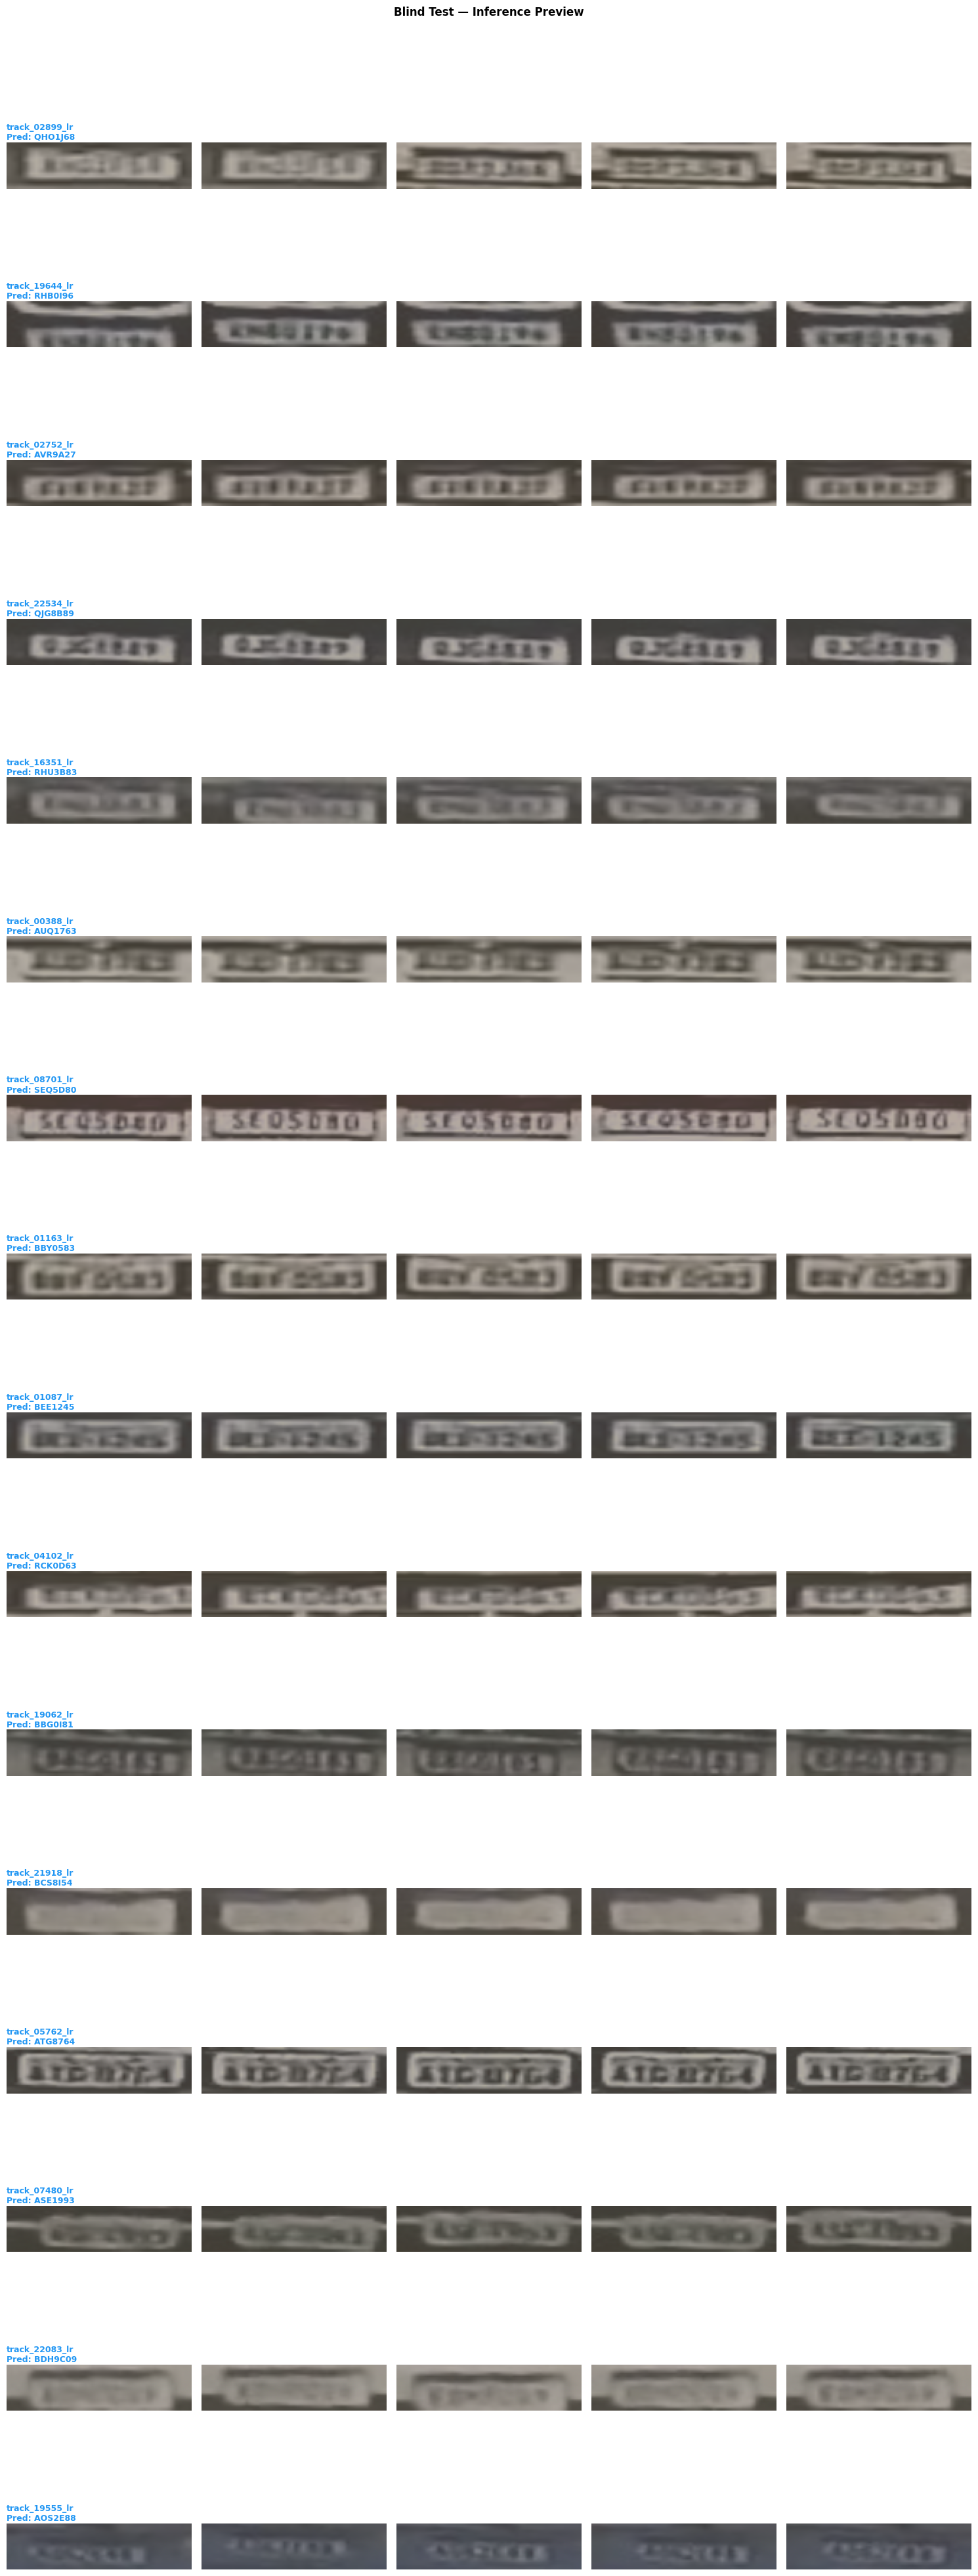

In [34]:
visualize_predictions(model, blind_test_loader, device=device, n_samples=16, mode='blind_test')